In [1]:
import os
os.environ["TF_USE_CUDNN"] = "0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

import os
os.environ["TF_USE_CUDNN"] = "0"

# -----------------------------
# Проверяем GPU
# -----------------------------
print("Devices:", tf.config.list_physical_devices())

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
data = pd.read_csv(
    './household_power_consumption.txt.gz',
    sep=';',
    na_values=['?', 'nan'],
    compression='gzip',
    low_memory=False
)

data['dt'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    dayfirst=True,
    errors='coerce'
)

data = data.set_index('dt').drop(columns=['Date','Time'])

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [4]:
df = data.copy()

In [5]:
df.isna().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [6]:
data_resampled_H = df.resample('h').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})

In [7]:
data_resampled_H.shape

(34589, 7)

In [8]:
mask_empty_hours = data_resampled_H['Global_active_power'].isna()
cols_sum = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

data_resampled_H.loc[mask_empty_hours, cols_sum] = \
    data_resampled_H.loc[mask_empty_hours, cols_sum].replace(0, np.nan)

In [9]:
data_resampled_H.isna().sum()

Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

In [10]:
data_resampled_H_copy = data_resampled_H.copy()

In [11]:
data_imputed_linear = data_resampled_H_copy.interpolate('linear')

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RNN, LSTMCell, Dense, LSTM, Conv1D, MaxPooling1D, Dropout, Input
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_directml(df, feature_cols, target_col,
                        seq_len=24, epochs=10, batch_size=24):

    # ---------- 1. Масштабирование ----------
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_all = scaler_X.fit_transform(df[feature_cols])
    y_all = scaler_y.fit_transform(df[[target_col]])

    # ---------- 2. Создание последовательностей ----------
    X_seq, y_seq = [], []

    for i in range(seq_len, len(df)):
        X_seq.append(X_all[i-seq_len:i])
        y_seq.append(y_all[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    # ---------- 3. Train/test split ----------
    train_size = int(len(X_seq) * 0.8)

    X_train = X_seq[:train_size]
    y_train = y_seq[:train_size]

    X_test = X_seq[train_size:]
    y_test = y_seq[train_size:]

    n_features = X_train.shape[2]

    # ---------- 4. LSTM БЕЗ CuDNN ----------

    model = Sequential()
    
    model.add(Input(shape=(seq_len, n_features)))
    model.add(RNN(LSTMCell(100), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(RNN(LSTMCell(70)))
    model.add(Dropout(0.3))
    model.add(Dense(1))
    
    model.compile(loss='mse', optimizer='adam')

    # -----------5. Тренировка
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True )
    
    history=model.fit(X_train,
                      y_train,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(X_test, y_test),
                      callbacks=[early_stop],
                      verbose=1,
                      shuffle=False)


    # ---------- 6. Предсказание ----------
    y_pred_scaled = model.predict(X_test)
    y_pred_train_scaled = model.predict(X_train)

    # ---------- 7. Обратная трансформация ----------
    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

    y_train_inv = scaler_y.inverse_transform(y_train)
    y_pred_train_inv = scaler_y.inverse_transform(y_pred_train_scaled)
    
    # ---------- 8. Metrics (TRAIN) ----------
    mae_train = mean_absolute_error(y_train_inv, y_pred_train_inv)
    mse_train = mean_squared_error(y_train_inv, y_pred_train_inv)
    r2_train = r2_score(y_train_inv, y_pred_train_inv)
    
    # ---------- 9. Metrics (TEST) ----------
    mae_test = mean_absolute_error(y_test_inv, y_pred_inv)
    mse_test = mean_squared_error(y_test_inv, y_pred_inv)
    r2_test = r2_score(y_test_inv, y_pred_inv)

    
    return (model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test,
                mae_train, mse_train, r2_train,
                mae_test, mse_test, r2_test
               )

In [13]:
target_col = 'Global_active_power'

In [14]:
target_col = 'Global_active_power'
feature_cols = data.columns.drop(target_col).tolist()
feature_cols

['Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3']

In [15]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, r2_train, mae_test, mse_test, r2_test = build_lstm_directml(
    data_imputed_linear,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=20,
    batch_size=1024  
)

Epoch 1/20
28/28 [==============================] - 5s 124ms/step - loss: 0.0255 - val_loss: 0.0117
Epoch 2/20
28/28 [==============================] - 3s 112ms/step - loss: 0.0189 - val_loss: 0.0113
Epoch 3/20
28/28 [==============================] - 3s 112ms/step - loss: 0.0184 - val_loss: 0.0111
Epoch 4/20
28/28 [==============================] - 3s 112ms/step - loss: 0.0174 - val_loss: 0.0105
Epoch 5/20
28/28 [==============================] - 3s 112ms/step - loss: 0.0164 - val_loss: 0.0099
Epoch 6/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0154 - val_loss: 0.0092
Epoch 7/20
28/28 [==============================] - 3s 115ms/step - loss: 0.0142 - val_loss: 0.0085
Epoch 8/20
28/28 [==============================] - 3s 114ms/step - loss: 0.0131 - val_loss: 0.0080
Epoch 9/20
28/28 [==============================] - 3s 115ms/step - loss: 0.0124 - val_loss: 0.0077
Epoch 10/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0120 - val_loss: 0.0075

In [16]:
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
print("TRAIN:")
print("MAE:", mae_train)
print("MSE:", mse_train)
print('RMSE', rmse_train)
print("R2:", r2_train)

print("\nTEST:")
print("MAE:", mae_test)
print("MSE:", mse_test)
print('RMSE', rmse_test)
print("R2:", r2_test)

TRAIN:
MAE: 0.4422864843123922
MSE: 0.37511438374159983
RMSE 0.6124658225089787
R2: 0.5671429249219287

TEST:
MAE: 0.38894416168888885
MSE: 0.27392193133032616
RMSE 0.5233755165560634
R2: 0.48227742602352486


In [17]:
metrics_df = pd.DataFrame([
    {
        "model_name": "LSTM_baseline",
        "dataset": "train",
        "mae": mae_train,
        "mse": mse_train,
        "rmse": rmse_train,
        "r2": r2_train
    },
    {
        "model_name": "LSTM_baseline",
        "dataset": "test",
        "mae": mae_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "r2": r2_test
    }
])

metrics_df

,model_name,dataset,mae,mse,rmse,r2
0,LSTM_baseline,train,0.442286,0.375114,0.612466,0.567143
1,LSTM_baseline,test,0.388944,0.273922,0.523376,0.482277


In [18]:
metrics_df.to_csv("baseline_model_metrics.csv", index=False)

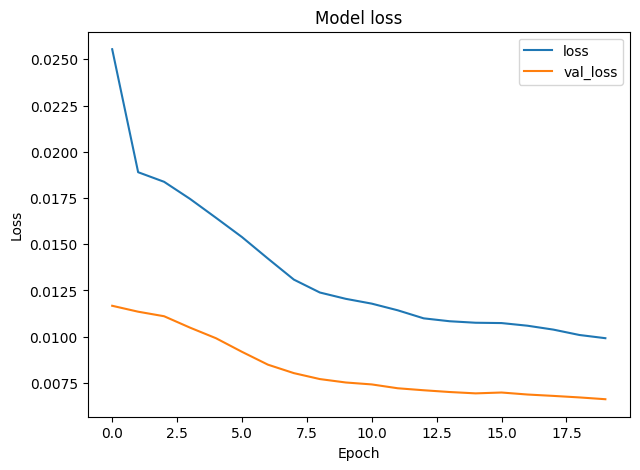

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

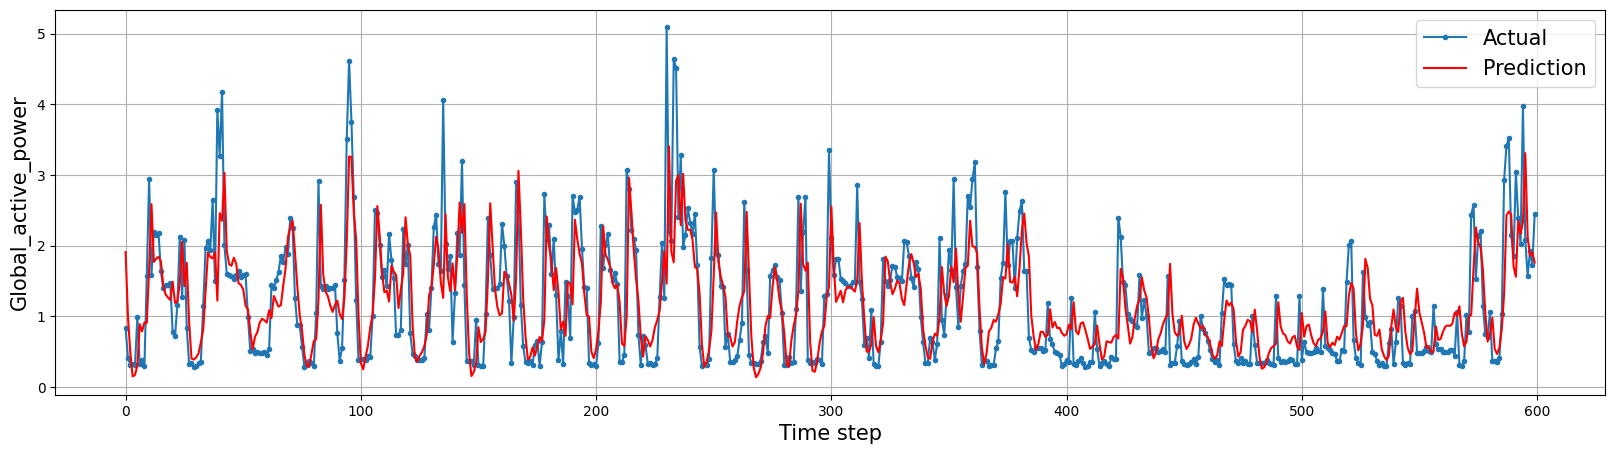

In [21]:
plt.figure(figsize=(20, 5))

# # Ограничим количество точек для визуализации
n = min(600, len(y_test_inv), len(y_pred_inv))
aa = range(n)

plt.plot(aa, y_test_inv[:n], marker='.', label='Actual')
plt.plot(aa, y_pred_inv[:n], 'r', label='Prediction')

plt.ylabel('Global_active_power', fontsize=15)
plt.xlabel('Time step', fontsize=15)
plt.legend(fontsize=15)
plt.grid(True)

plt.show()

6913 6913 6913


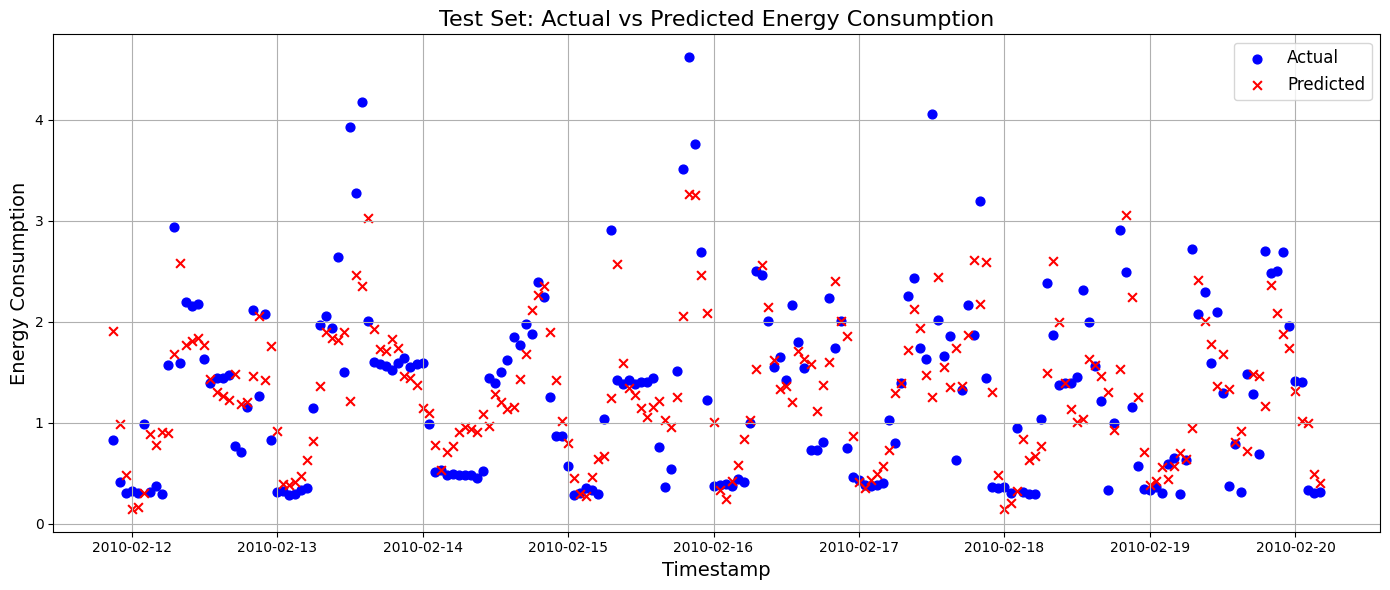

In [22]:
import matplotlib.pyplot as plt

# Восстанавливаем индекс тестовой части
seq_len = 24  # тот же, что в функции
train_size = int((len(data_imputed_linear) - seq_len) * 0.8)

# Количество последовательностей = len(df) - seq_len
target_index = data_imputed_linear.index[seq_len:]
test_index = target_index[train_size:]

# Проверка длины
print(len(test_index), len(y_test_inv), len(y_pred_inv))

# Строим график
n = 200  # сколько точек показать

plt.figure(figsize=(14, 6))
plt.scatter(test_index[:n], y_test_inv[:n],
            label='Actual', marker='o', color='blue', s=40)
plt.scatter(test_index[:n], y_pred_inv[:n],
            label='Predicted', marker='x', color='red', s=40)

plt.title('Test Set: Actual vs Predicted Energy Consumption', fontsize=16)
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('Energy Consumption', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
def permutation_importance(model, X_test, y_test, feature_names):
    baseline_pred = model.predict(X_test)
    baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

    importances = []

    for i, name in enumerate(feature_names):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, :, i])  # перемешиваем один признак

        perm_pred = model.predict(X_perm)
        perm_rmse = mean_squared_error(y_test, perm_pred) ** 0.5

        importances.append((name, perm_rmse - baseline_rmse))

    return sorted(importances, key=lambda x: x[1], reverse=True)

In [24]:
importances = permutation_importance(model, X_test, y_test, feature_cols)

217/217 [==============================] - 3s 13ms/step


In [25]:
for name, score in importances:
    print(f"{name:20s}  ΔRMSE = {score:.5f}")

Global_intensity      ΔRMSE = 0.04637
Sub_metering_3        ΔRMSE = 0.00589
Voltage               ΔRMSE = 0.00393
Global_reactive_power  ΔRMSE = 0.00098
Sub_metering_2        ΔRMSE = 0.00052
Sub_metering_1        ΔRMSE = 0.00045


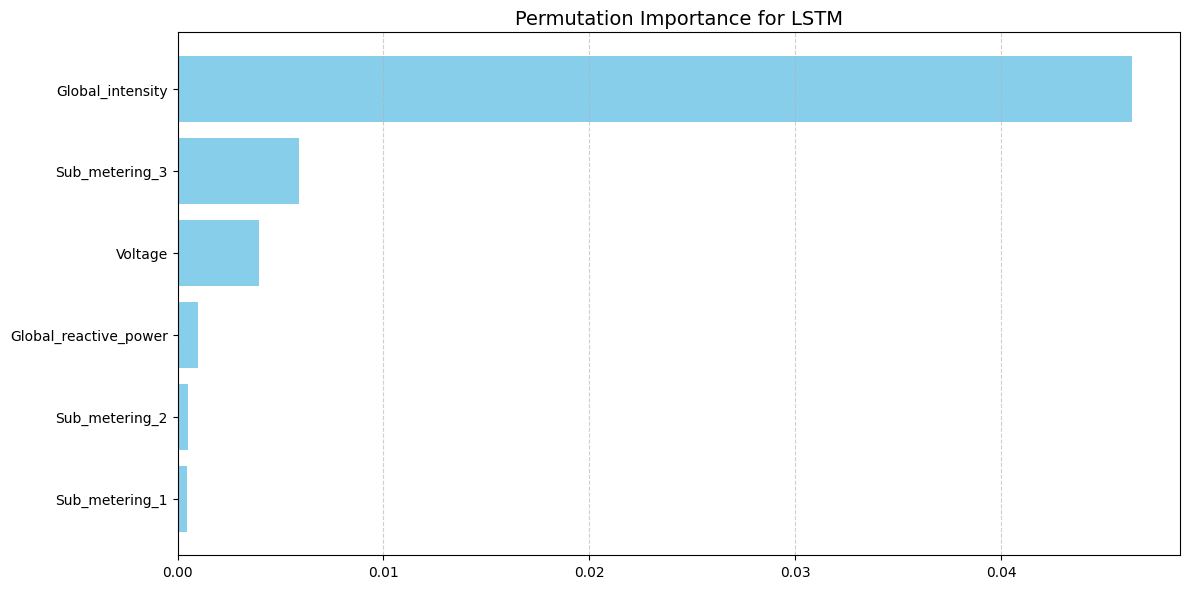

In [30]:
# Разворачиваем в два списка
features = [f[0] for f in importances]
scores = [f[1] for f in importances]

plt.figure(figsize=(12, 6))
plt.barh(features, scores, color='skyblue')
plt.title("Permutation Importance for LSTM", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()  # чтобы важные признаки были сверху
plt.tight_layout()
plt.show()